IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


In [3]:
import os

os.listdir(path)

['airports.csv', 'airlines.csv', 'flights.csv']

Flights.csv DATA SET

In [4]:
df = pd.read_csv(f"{path}/flights.csv")
df.head(-10)

/tmp/ipykernel_20857/1221432855.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819064,2015,12,31,4,UA,668,N66848,LAS,IAD,2359,...,652.0,-29.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819065,2015,12,31,4,UA,671,N33209,PDX,IAH,2359,...,545.0,-19.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819066,2015,12,31,4,UA,1849,N497UA,LAS,EWR,2359,...,718.0,-24.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819067,2015,12,31,4,AA,2342,N3DLAA,DEN,MIA,2359,...,525.0,-18.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


airlines.csv DATA SET

In [5]:
airlines = pd.read_csv(f"{path}/airlines.csv")
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


airport.csv DATA SET

In [6]:
airports = pd.read_csv(f"{path}/airports.csv")
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


DATA SET SHAPE

In [7]:
df.shape

(5819079, 31)

DATA SET INFORMATION

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

DESCRIBING THE DATA SET

In [9]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


MISSING VALUES

In [10]:
df.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [11]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset, so no need to remove duplicate records.

In [12]:
missing = df.isnull().sum()
missing[missing > 0]

,0
TAIL_NUMBER,14721
DEPARTURE_TIME,86153
DEPARTURE_DELAY,86153
TAXI_OUT,89047
WHEELS_OFF,89047
SCHEDULED_TIME,6
ELAPSED_TIME,105071
AIR_TIME,105071
WHEELS_ON,92513
TAXI_IN,92513


MISSING VALUES PERCENTAGE

In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0
CANCELLATION_REASON,98.455357
SECURITY_DELAY,81.724960
AIR_SYSTEM_DELAY,81.724960
LATE_AIRCRAFT_DELAY,81.724960
WEATHER_DELAY,81.724960
AIRLINE_DELAY,81.724960
ARRIVAL_DELAY,1.805629
ELAPSED_TIME,1.805629
AIR_TIME,1.805629
TAXI_IN,1.589822



 CANCELLED FILGHTS

In [14]:
df["CANCELLED"].value_counts()

,count
CANCELLED,
0,5729195
1,89884


In [15]:
df[df["ARRIVAL_DELAY"].isnull()].head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
32,2015,1,1,4,AS,136,N431AS,ANC,SEA,135,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
42,2015,1,1,4,AA,2459,N3BDAA,PHX,DFW,200,...,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
68,2015,1,1,4,OO,5254,N746SK,MAF,IAH,510,...,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
82,2015,1,1,4,MQ,2859,N660MQ,SGF,DFW,525,...,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
90,2015,1,1,4,OO,5460,N583SW,RDD,SFO,530,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN


REMOVE CANCELLED FLIGHTS

In [16]:
df = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0)
]

In [17]:
df["CANCELLED"].value_counts()

,count
CANCELLED,
0,5714008


In [18]:
df["DIVERTED"].value_counts()

,count
DIVERTED,
0,5714008


CHECK MISSING VALUES AGAIN

In [19]:
missing = df.isnull().sum()
missing[missing > 0]

,0
CANCELLATION_REASON,5714008
AIR_SYSTEM_DELAY,4650569
SECURITY_DELAY,4650569
AIRLINE_DELAY,4650569
LATE_AIRCRAFT_DELAY,4650569
WEATHER_DELAY,4650569


FILL MISSING VALUES

In [20]:
delay_columns = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

df[delay_columns] = df[delay_columns].fillna(0)

In [21]:
missing = df.isnull().sum()
missing[missing > 0]

,0
CANCELLATION_REASON,5714008


BECAUSE WE DONT NEED THIS COLUMN

In [22]:
df = df.drop(columns=["CANCELLATION_REASON"])

In [23]:
missing = df.isnull().sum()
missing[missing > 0]

,0


NOW WE REMOVE THE REMAINING MISSING VALUES

In [24]:
df = df.dropna()

In [25]:
missing = df.isnull().sum()
missing[missing > 0]

,0


In [26]:
airlines = airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"})

In [27]:
df = df.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left"
)

In [28]:
df = df.drop(columns=["IATA_CODE"])

In [29]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,0.0,0.0,0.0,0.0,0.0,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.


In [30]:
df["ORIGIN_AIRPORT"].head(10)

,ORIGIN_AIRPORT
0,ANC
1,LAX
2,SFO
3,LAX
4,SEA
5,SFO
6,LAS
7,LAX
8,SFO
9,LAS


In [31]:
airports = airports.rename(columns={"AIRPORT": "ORIGIN_AIRPORT_NAME"})

In [32]:
df = df.merge(
    airports[["IATA_CODE", "ORIGIN_AIRPORT_NAME"]],
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

In [33]:
df = df.drop(columns=["IATA_CODE"])

In [34]:
df.shape

(5714008, 32)

UNIVARIATE ANALYSIS


In [35]:
df["AIRLINE"].value_counts()

,count
AIRLINE,
WN,1242403
DL,870275
AA,712935
OO,576814
EV,554752
UA,507762
MQ,278791
B6,262042
US,194223


FLIGHTS BY AIRLINE

/tmp/ipykernel_20857/4150191499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


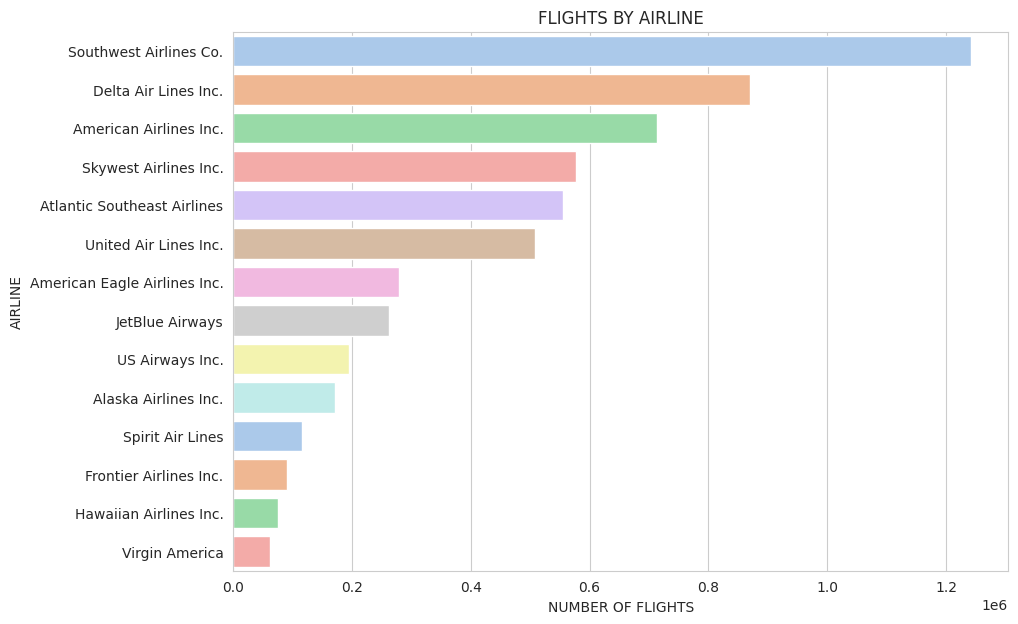

In [36]:
plt.figure(figsize=(10,7))

sns.countplot(
    data=df,
    y="AIRLINE_NAME",
    order=df["AIRLINE_NAME"].value_counts().index,
    palette="pastel"
)

plt.title("FLIGHTS BY AIRLINE")
plt.xlabel("NUMBER OF FLIGHTS")
plt.ylabel("AIRLINE")

plt.show()

INSIGHT: Southwest Airlines operated the highest number of flights, while Virgin America had the fewest flights in the dataset

AVERAGE ARRIVAL DELAY BY AIRLINE

/tmp/ipykernel_20857/1082966466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


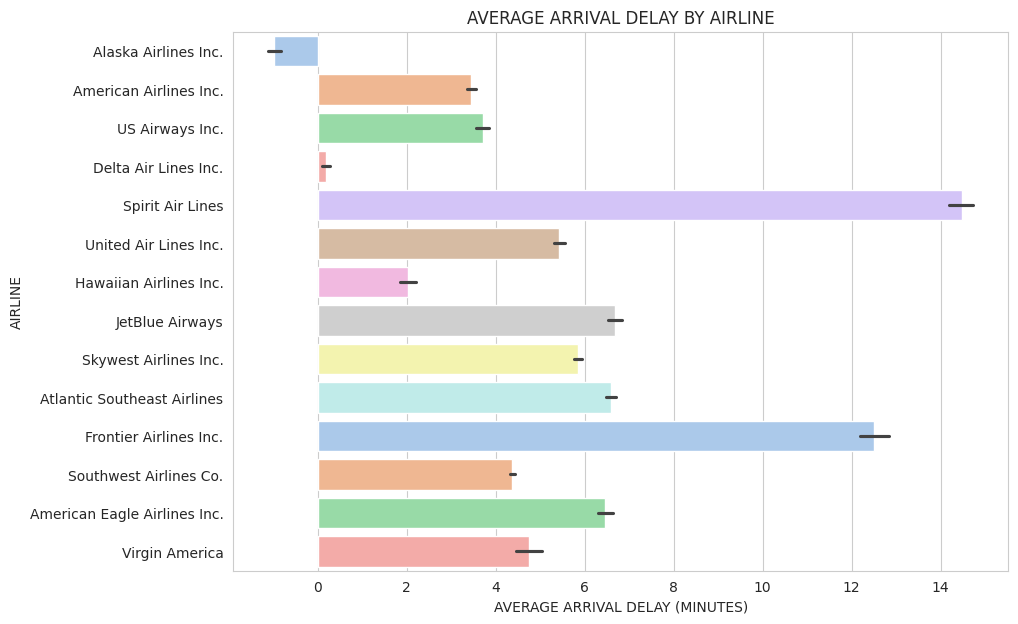

In [37]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=df,
    y="AIRLINE_NAME",
    x="ARRIVAL_DELAY",
    estimator="mean",
    palette="pastel",
)

plt.title("AVERAGE ARRIVAL DELAY BY AIRLINE")
plt.xlabel("AVERAGE ARRIVAL DELAY (MINUTES)")
plt.ylabel("AIRLINE")

plt.show()

INSIGHT: Some airlines operated fewer flights but had higher average arrival delays

AVERAGE ARRIVAL DELAY BY MONTH

/tmp/ipykernel_20857/1811982121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


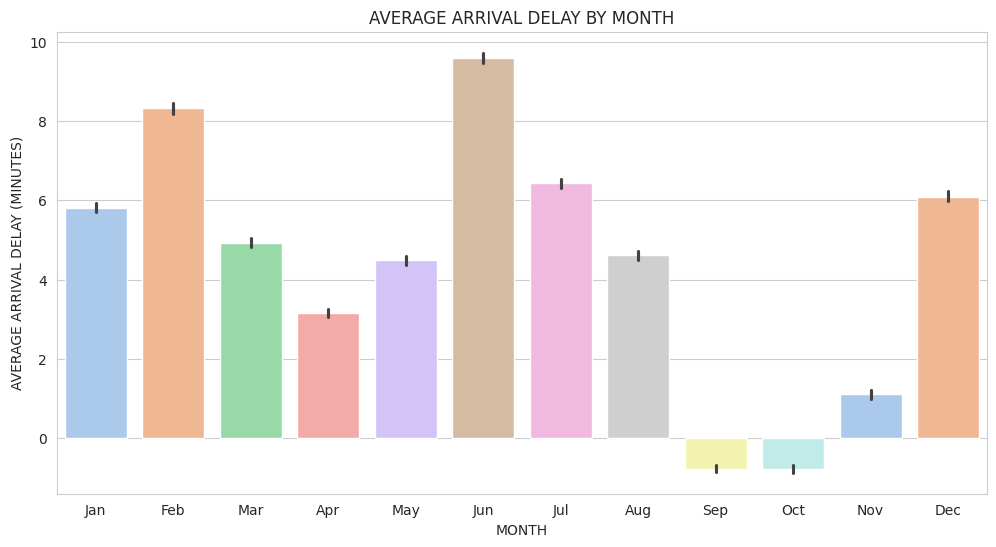

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="MONTH",
    y="ARRIVAL_DELAY",
    estimator="mean",
    palette="pastel",
)

plt.title("AVERAGE ARRIVAL DELAY BY MONTH")
plt.xlabel("MONTH")
plt.ylabel("AVERAGE ARRIVAL DELAY (MINUTES)")

plt.xticks(
    ticks=range(12),
    labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.show()

INSIGHT: Flight delays varied across the months indicating seasonal changes in flight performance

In [39]:
df["MONTH"].value_counts().sort_index()

,count
MONTH,
1,457013
2,407663
3,492138
4,479251
5,489641
6,492847
7,514384
8,503956
9,462153


In [40]:
sample_df = df.sample(10000, random_state=42)

DEPARTURE DELAY VS ARRIVAL DELAY

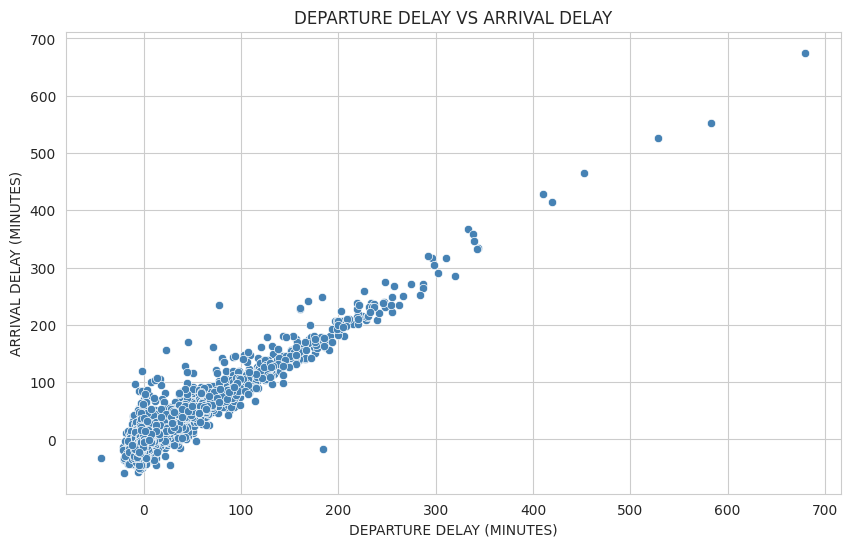

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="DEPARTURE_DELAY",
    y="ARRIVAL_DELAY",
    color="steelblue"

)

plt.title("DEPARTURE DELAY VS ARRIVAL DELAY")
plt.xlabel("DEPARTURE DELAY (MINUTES)")
plt.ylabel("ARRIVAL DELAY (MINUTES)")

plt.show()

INSIGHT: Flights with higher departure delays generally also HAVE higher arrival delays showing a strong positive relationship

TOP 10 ORIGIN AIRPORTS WITH HIGHEST AVERAGE DELAY

In [42]:
top_airports = (
    df.groupby("ORIGIN_AIRPORT")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

/tmp/ipykernel_20857/3644276030.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


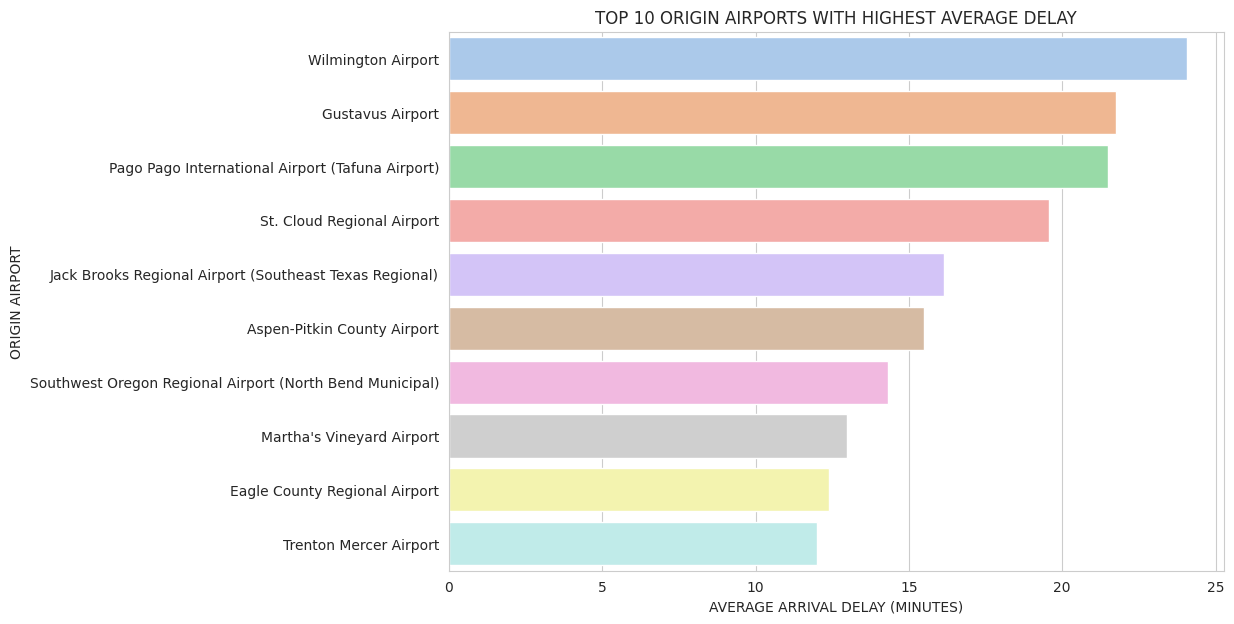

In [43]:
top_airports = (
    df.groupby("ORIGIN_AIRPORT_NAME")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_airports.values,
    y=top_airports.index,
    palette="pastel"
)

plt.title("TOP 10 ORIGIN AIRPORTS WITH HIGHEST AVERAGE DELAY")
plt.xlabel("AVERAGE ARRIVAL DELAY (MINUTES)")
plt.ylabel("ORIGIN AIRPORT")

plt.show()

INSIGHT: A small number of origin airports have much higher average arrival delays than the rest while most airports have lower average delays

CORRELATION HEATMAP

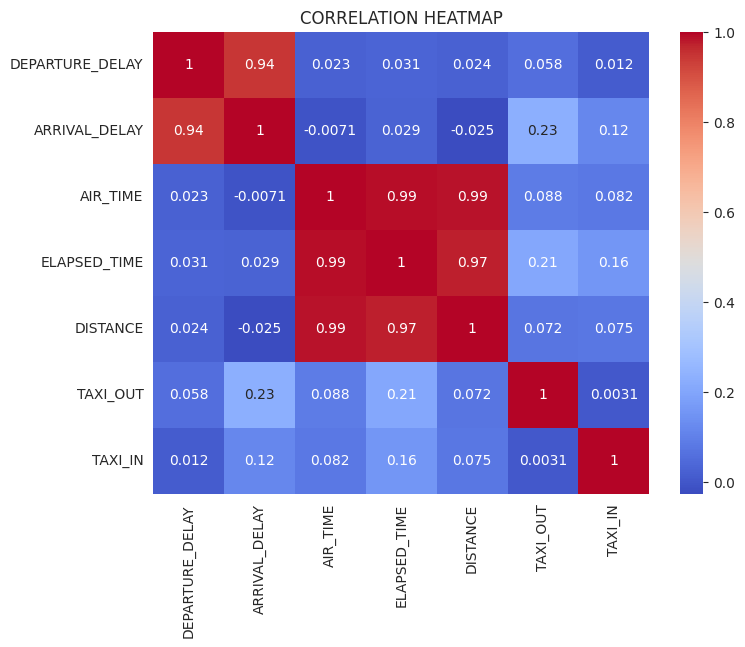

In [44]:
plt.figure(figsize=(8,6))

columns = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "AIR_TIME",
    "ELAPSED_TIME",
    "DISTANCE",
    "TAXI_OUT",
    "TAXI_IN"
]

sns.heatmap(
    df[columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("CORRELATION HEATMAP")

plt.show()

INSIGHT: Departure delay had the strongest correlation with arrival delay, telling that late departures are the main driver of late arrivals

FEATURE ENGINEERING



In [45]:
df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] >= 15).astype(int)

In [46]:
df["IS_DELAYED"].value_counts()

,count
IS_DELAYED,
0,4650569
1,1063439


DELAYED VS ON-TIME FLIGHTS

/tmp/ipykernel_20857/4275556614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


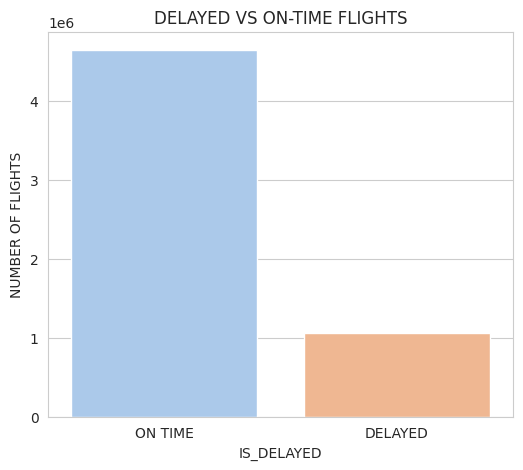

In [47]:



plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="IS_DELAYED",
    palette="pastel"
)

plt.title("DELAYED VS ON-TIME FLIGHTS")
plt.xlabel("IS_DELAYED")
plt.ylabel("NUMBER OF FLIGHTS")
plt.xticks([0,1], ["ON TIME","DELAYED"])

plt.show()

INSIGHT: Most flights arrived on time or with delays of 15 minutes or less.

In [48]:
small_df = (
    df.groupby("MONTH", group_keys=False)
      .apply(lambda x: x.sample(n=8000, random_state=42))
      .reset_index(drop=True)
)

small_df.to_csv("small_clean_data_v2.csv", index=False)

/tmp/ipykernel_20857/1954394640.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=8000, random_state=42))


In [49]:
small_df["MONTH"].value_counts().sort_index()

,count
MONTH,
1,8000
2,8000
3,8000
4,8000
5,8000
6,8000
7,8000
8,8000
9,8000


PREPARE MODEL DATA

In [50]:
features = [
    'MONTH',
    'DAY',
    'DAY_OF_WEEK',
    'AIRLINE_NAME',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE'
]

#i didnt use arrival delay or departue delay because its like cheating the model which is called leak

In [51]:
X = small_df[features]
y = small_df["IS_DELAYED"]

In [52]:
X = pd.get_dummies(
    X,
    columns=['AIRLINE_NAME'],
    drop_first=True
)

In [53]:
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
print("X Train:", X_train_classification.shape)
print("X Test:", X_test_classification.shape)
print("Y Train:", y_train_classification.shape)
print("Y Test:", y_test_classification.shape)

X Train: (76800, 19)
X Test: (19200, 19)
Y Train: (76800,)
Y Test: (19200,)


XGBOOST CLASSIFICATION MODEL

In [55]:
negative_count = (y_train_classification == 0).sum()
positive_count = (y_train_classification == 1).sum()

class_weight = negative_count / positive_count

model_classification = XGBClassifier(
    random_state=42,
    scale_pos_weight=class_weight
)

model_classification.fit(
    X_train_classification,
    y_train_classification
)

y_pred_classification = model_classification.predict(
    X_test_classification
)

In [56]:
accuracy = accuracy_score(
    y_test_classification,
    y_pred_classification
)


print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 66.6 %


In [57]:
print(
    classification_report(
        y_test_classification,
        y_pred_classification
    )
)

              precision    recall  f1-score   support

           0       0.88      0.69      0.77     15629
           1       0.29      0.57      0.39      3571

    accuracy                           0.67     19200
   macro avg       0.58      0.63      0.58     19200
weighted avg       0.77      0.67      0.70     19200



In [58]:
cm = confusion_matrix(
    y_test_classification,
    y_pred_classification
)

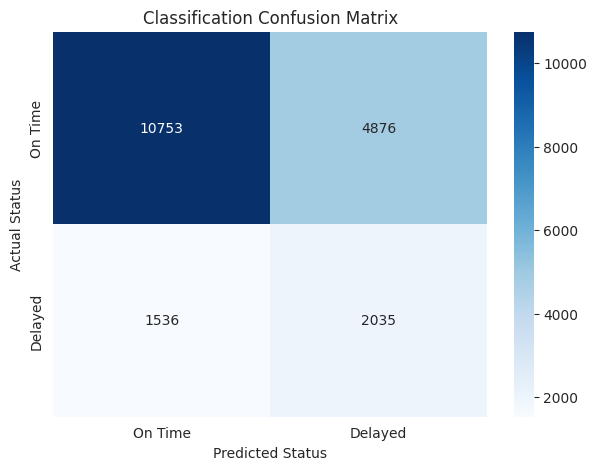

In [59]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['On Time', 'Delayed'],
    yticklabels=['On Time', 'Delayed']
)

plt.title('Classification Confusion Matrix')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')

plt.show()

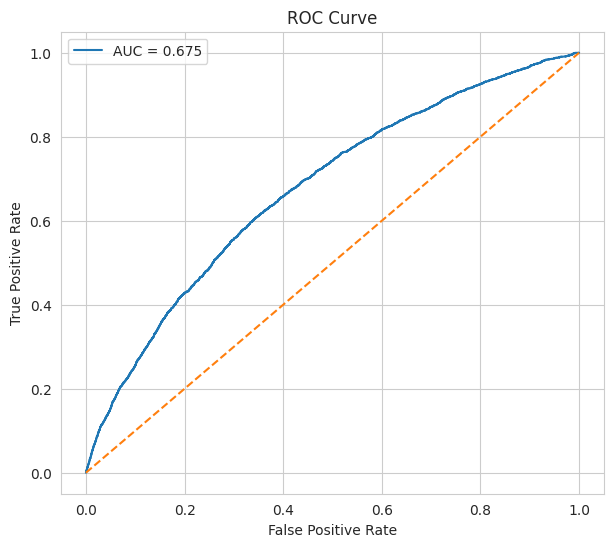

In [60]:
y_prob = model_classification.predict_proba(X_test_classification)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test_classification,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

XGBOOST REGRESSION MODEL

In [61]:
X = df[
    [
        'DEPARTURE_DELAY',
        'DISTANCE',
        'MONTH',
        'DAY',
        'DAY_OF_WEEK'
    ]
]

y = df['ARRIVAL_DELAY']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
model_regression = XGBRegressor(
    random_state=42
)

In [64]:
model_regression.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
y_pred_regression = model_regression.predict(
    X_test
)

In [66]:
rmse = root_mean_squared_error(
    y_test,
    y_pred_regression
)

mae = mean_absolute_error(
    y_test,
    y_pred_regression
)

r2 = r2_score(
    y_test,
    y_pred_regression
)

print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))
print("R2:", round(r2, 2))

RMSE: 15.67
MAE: 9.16
R2: 0.84


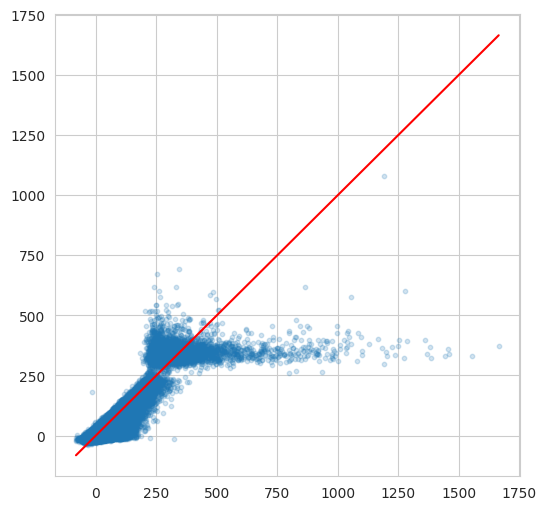

In [67]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_regression,
    alpha=0.2,
    s=10
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

In [68]:
import joblib

joblib.dump(
    model_classification,
    'xgb_classification_model.pkl'
)

joblib.dump(
    model_regression,
    'xgb_regression_model.pkl'
)

['xgb_regression_model.pkl']